# Домашнее задание 1. Знакомство с API
Студент: __Соловьев Егор Николаевич, М08-501НД, 28.03.2026__

Задание выполняется в рамках модуля 1 «Проектирование API». Вы закрепите навыки разработки API, используя подход API-first.

> Чтобы получить максимальный балл, убедитесь, что ваш ноутбук запускается с нуля, структура понятна, а в выводах вы объясняете свои решения.  

## Подготовка окружения

In [1]:
!pip install requests -qqq

### Задание 1. Создать CRUD на основе встроенного HTTP сервера Python

Задача: создать сервер, который будет содержать код API с двумя методами HTTP.

*Здесь мы **специально** берем сильно устаревшую версию веб-сервера, написанную во времена Python 2.0 в 2000 году. Обратите внимание на многословность кода веб-сервера.*


In [2]:
import pandas as pd
import datetime

df = pd.DataFrame([['Антифриз EURO G11 (-45°С) зеленый, силикатный 5кг',
  1025,
  329,
  11,
  'c',
  'антифриз',
  datetime.datetime(2026, 10, 16, 12, 36, 22)],
 ['Антифриз готовый фиолетовый Синтек MULTIFREEZE 5кг',
  250,
  315,
  38,
  'b',
  'антифриз',
  datetime.datetime(2025, 12, 11, 8, 25, 31)],
 ['Антифриз G11 зеленый',
  120,
  329,
  61,
  'b',
  'антифриз',
  datetime.datetime(2025, 6, 15, 15, 36, 30)],
 ['Антифриз Antifreeze OEM China OAT red -40 5кг',
  390,
  504,
  65,
  'c',
  'антифриз',
  datetime.datetime(2025, 11, 30, 4, 12, 39)],
 ['Антифриз G11 зеленый',
  135,
  407,
  93,
  'b',
  'антифриз',
  datetime.datetime(2026, 8, 25, 3, 24, 1)],
])

df.columns = ['Наименование товара', 'Цена, руб.', 'cpm', 'Скидка', 'tp', 'Категория', 'dt']
df['Год'] = df['dt'].dt.year
df=df.drop(['cpm',  'tp', 'dt'],axis=1)
display(df)


,Наименование товара,"Цена, руб.",Скидка,Категория,Год
0,"Антифриз EURO G11 (-45°С) зеленый, силикатный 5кг",1025,11,антифриз,2026
1,Антифриз готовый фиолетовый Синтек MULTIFREEZE...,250,38,антифриз,2025
2,Антифриз G11 зеленый,120,61,антифриз,2025
3,Антифриз Antifreeze OEM China OAT red -40 5кг,390,65,антифриз,2025
4,Антифриз G11 зеленый,135,93,антифриз,2026


In [ ]:
import http.server
import socketserver
import json
import re
import threading

# --- In-memory database ---
items_db = {str(k): v for k, v in df.to_dict(orient="index").items()}
next_id = len(items_db)

def run_server():
    print(f"Serving at port {PORT} in a separate thread...")
    httpd.serve_forever()

def stop_server(server):
    print("Stopping server...")
    server.shutdown()
    server.server_close()
    print("Server stopped.")

class SimpleCRUDHandler(http.server.BaseHTTPRequestHandler):

    def _send_json_response(self, status_code, data=None):
        self.send_response(status_code)
        self.send_header('Content-type', 'application/json')
        self.end_headers()
        if data is not None:
            self.wfile.write(json.dumps(data).encode('utf-8'))

    def _parse_json_body(self):
        content_length = int(self.headers['Content-Length'])
        body = self.rfile.read(content_length)
        try:
            return json.loads(body.decode('utf-8'))
        except json.JSONDecodeError:
            return None

    def do_GET(self):
        global items_db
        match_all = re.match(r'^/items/?$', self.path)
        match_single = re.match(r'^/items/([0-9]+)/?$', self.path)

        if match_all:
            self._send_json_response(200, [items_db])
        elif match_single:
            item_id = match_single.group(1)
            if item_id in items_db:
                self._send_json_response(200, items_db[item_id])
            else:
                self._send_json_response(404, {'detail': 'Item not found'})
        else:
            self._send_json_response(404, {'detail': 'Not Found'})

    def do_POST(self):
        global items_db, next_id
        match = re.match(r'^/items/?$', self.path)
        if match:
            data = self._parse_json_body()
            if data:
                new_id = str(next_id)
                next_id += 1
                items_db[new_id] = data
                self._send_json_response(201, {'created': data})
            else:
                self._send_json_response(400, {'detail': 'Invalid JSON'})
        else:
            self._send_json_response(404, {'detail': 'Not Found'})


PORT = 8000
httpd = socketserver.TCPServer(("localhost", PORT), SimpleCRUDHandler)

server_thread = threading.Thread(target=run_server)
server_thread.daemon = True
server_thread.start()

print(f"Server started on port {PORT}. Use server_thread.join() to wait for it or stop_server() to stop it.")

Serving at port 8000 in a separate thread...Server started on port 8000. Use server_thread.join() to wait for it or stop_server() to stop it.



127.0.0.1 - - [26/Mar/2026 17:24:37] "GET /items HTTP/1.1" 200 -
127.0.0.1 - - [26/Mar/2026 17:24:44] "GET /items/1 HTTP/1.1" 200 -
127.0.0.1 - - [26/Mar/2026 17:24:48] "GET /items/2 HTTP/1.1" 200 -
127.0.0.1 - - [26/Mar/2026 17:24:48] "GET /items/2 HTTP/1.1" 200 -
127.0.0.1 - - [26/Mar/2026 17:24:50] "GET /items/2/3 HTTP/1.1" 404 -
127.0.0.1 - - [26/Mar/2026 17:24:54] "GET /items/3/ HTTP/1.1" 200 -
127.0.0.1 - - [26/Mar/2026 17:24:55] "GET /items/3/ HTTP/1.1" 200 -
127.0.0.1 - - [26/Mar/2026 17:24:57] "GET /items/4 HTTP/1.1" 200 -
127.0.0.1 - - [26/Mar/2026 17:24:58] "GET /items/5 HTTP/1.1" 404 -
127.0.0.1 - - [26/Mar/2026 17:25:00] "GET /items/5 HTTP/1.1" 404 -
127.0.0.1 - - [26/Mar/2026 17:25:03] "GET / HTTP/1.1" 404 -


### Задание 2. Подключиться к этому серверу

Подумайте, какие глаголы HTTP нужно использовать для разных методов запроса

```python
import requests
try:
    url = "http://127.0.0.1:8000/items"
    response = requests.get(url)
    print(response.json()[0]['0'])
except Exception as e:
    print(f"Ошибка: {e}")
```

Сервер должен отвечать валидным JSON. Содержание JSONa не важно, главное, чтобы он был валидным.


In [4]:
import requests

# проверяю REST API через метод GET
try:
    url = "http://127.0.0.1:8000/items"
    response = requests.get(url)  # GET
    print(response.json()[0]['0'])
except Exception as e:
    print(f"Ошибка: {e}")

{'Наименование товара': 'Антифриз EURO G11 (-45°С) зеленый, силикатный 5кг', 'Цена, руб.': 1025, 'Скидка': 11, 'Категория': 'антифриз', 'Год': 2026}


127.0.0.1 - - [26/Mar/2026 17:25:20] "GET /items HTTP/1.1" 200 -


127.0.0.1 - - [26/Mar/2026 17:25:32] "POST /items HTTP/1.1" 201 -
127.0.0.1 - - [26/Mar/2026 17:25:41] "GET /items HTTP/1.1" 200 -


In [5]:
# добавляю новый элемент через метод POST

url = "http://127.0.0.1:8000/items"
new_item = {
    'Наименование товара': 'Антифриз готовый пурпурный 10кг',
    'Цена, руб.': 1111,
    'Скидка': 55,
    'Категория': 'НОВЫЙ антифриз',
    'Год': 2026
}
response = requests.post(url, json=new_item)  # POST
print(response.json())

{'created': {'Наименование товара': 'Антифриз готовый пурпурный 10кг', 'Цена, руб.': 1111, 'Скидка': 55, 'Категория': 'НОВЫЙ антифриз', 'Год': 2026}}


127.0.0.1 - - [26/Mar/2026 17:25:50] "POST /items HTTP/1.1" 201 -


In [6]:
def pretty_json_response(res, i_list: int=None, i_item: str=None):
    """
    Возвращает отформатированный JSON из ответа requests.

    Args:
        res: объект requests.Response.
        i_list (int, optional): индекс элемента в списке, если ответ — список.
        i_item (str, optional): ключ в словаре, если ответ — словарь.

    Returns:
        str: JSON-строка с отступами (indent=4), ensure_ascii=False.
    """
    if i_list != None and i_item != None:
        return json.dumps(res.json()[i_list][i_item],
                          indent=4,
                          ensure_ascii=False)
    elif i_item == None and i_list != None:
        return json.dumps(res.json()[i_list],
                          indent=4,
                          ensure_ascii=False)
    elif i_item == None and i_list == None:
        return json.dumps(res.json(),
                          indent=4,
                          ensure_ascii=False)

# проверяю наличие нового элемента в базе, это 5й через метод GET
try:
    response = requests.get(url)  # GET
    print(pretty_json_response(response, 0))
except Exception as e:
    print(f"Ошибка: {e}")

{
    "0": {
        "Наименование товара": "Антифриз EURO G11 (-45°С) зеленый, силикатный 5кг",
        "Цена, руб.": 1025,
        "Скидка": 11,
        "Категория": "антифриз",
        "Год": 2026
    },
    "1": {
        "Наименование товара": "Антифриз готовый фиолетовый Синтек MULTIFREEZE 5кг",
        "Цена, руб.": 250,
        "Скидка": 38,
        "Категория": "антифриз",
        "Год": 2025
    },
    "2": {
        "Наименование товара": "Антифриз G11 зеленый",
        "Цена, руб.": 120,
        "Скидка": 61,
        "Категория": "антифриз",
        "Год": 2025
    },
    "3": {
        "Наименование товара": "Антифриз Antifreeze OEM China OAT red -40 5кг",
        "Цена, руб.": 390,
        "Скидка": 65,
        "Категория": "антифриз",
        "Год": 2025
    },
    "4": {
        "Наименование товара": "Антифриз G11 зеленый",
        "Цена, руб.": 135,
        "Скидка": 93,
        "Категория": "антифриз",
        "Год": 2026
    },
    "5": {
        "Наименование товар

127.0.0.1 - - [26/Mar/2026 17:25:54] "GET /items HTTP/1.1" 200 -


In [7]:
# проверяю возвращение JSON представления
!curl http://localhost:8000/items  # GET JSON

[{"0": {"\u041d\u0430\u0438\u043c\u0435\u043d\u043e\u0432\u0430\u043d\u0438\u0435 \u0442\u043e\u0432\u0430\u0440\u0430": "\u0410\u043d\u0442\u0438\u0444\u0440\u0438\u0437 EURO G11 (-45\u00b0\u0421) \u0437\u0435\u043b\u0435\u043d\u044b\u0439, \u0441\u0438\u043b\u0438\u043a\u0430\u0442\u043d\u044b\u0439 5\u043a\u0433", "\u0426\u0435\u043d\u0430, \u0440\u0443\u0431.": 1025, "\u0421\u043a\u0438\u0434\u043a\u0430": 11, "\u041a\u0430\u0442\u0435\u0433\u043e\u0440\u0438\u044f": "\u0430\u043d\u0442\u0438\u0444\u0440\u0438\u0437", "\u0413\u043e\u0434": 2026}, "1": {"\u041d\u0430\u0438\u043c\u0435\u043d\u043e\u0432\u0430\u043d\u0438\u0435 \u0442\u043e\u0432\u0430\u0440\u0430": "\u0410\u043d\u0442\u0438\u0444\u0440\u0438\u0437 \u0433\u043e\u0442\u043e\u0432\u044b\u0439 \u0444\u0438\u043e\u043b\u0435\u0442\u043e\u0432\u044b\u0439 \u0421\u0438\u043d\u0442\u0435\u043a MULTIFREEZE 5\u043a\u0433", "\u0426\u0435\u043d\u0430, \u0440\u0443\u0431.": 250, "\u0421\u043a\u0438\u0434\u043a\u0430": 38, "\u041a

127.0.0.1 - - [26/Mar/2026 17:26:13] "GET /items HTTP/1.1" 200 -


In [9]:
# проверяю возвращение JSON представления
!curl http://localhost:8000/items/0  # GET JSON

{"\u041d\u0430\u0438\u043c\u0435\u043d\u043e\u0432\u0430\u043d\u0438\u0435 \u0442\u043e\u0432\u0430\u0440\u0430": "\u0410\u043d\u0442\u0438\u0444\u0440\u0438\u0437 EURO G11 (-45\u00b0\u0421) \u0437\u0435\u043b\u0435\u043d\u044b\u0439, \u0441\u0438\u043b\u0438\u043a\u0430\u0442\u043d\u044b\u0439 5\u043a\u0433", "\u0426\u0435\u043d\u0430, \u0440\u0443\u0431.": 1025, "\u0421\u043a\u0438\u0434\u043a\u0430": 11, "\u041a\u0430\u0442\u0435\u0433\u043e\u0440\u0438\u044f": "\u0430\u043d\u0442\u0438\u0444\u0440\u0438\u0437", "\u0413\u043e\u0434": 2026}

127.0.0.1 - - [26/Mar/2026 17:26:28] "GET /items/0 HTTP/1.1" 200 -


In [10]:
# проверяю возвращение JSON представления
!curl http://localhost:8000/items/1  # GET JSON

{"\u041d\u0430\u0438\u043c\u0435\u043d\u043e\u0432\u0430\u043d\u0438\u0435 \u0442\u043e\u0432\u0430\u0440\u0430": "\u0410\u043d\u0442\u0438\u0444\u0440\u0438\u0437 \u0433\u043e\u0442\u043e\u0432\u044b\u0439 \u0444\u0438\u043e\u043b\u0435\u0442\u043e\u0432\u044b\u0439 \u0421\u0438\u043d\u0442\u0435\u043a MULTIFREEZE 5\u043a\u0433", "\u0426\u0435\u043d\u0430, \u0440\u0443\u0431.": 250, "\u0421\u043a\u0438\u0434\u043a\u0430": 38, "\u041a\u0430\u0442\u0435\u0433\u043e\u0440\u0438\u044f": "\u0430\u043d\u0442\u0438\u0444\u0440\u0438\u0437", "\u0413\u043e\u0434": 2025}

127.0.0.1 - - [26/Mar/2026 17:26:35] "GET /items/1 HTTP/1.1" 200 -


In [11]:
# останавливаю сервер
stop_server(httpd)

Stopping server...
Server stopped.


### Задание 3. Описать эндпоинты сервера и их методы в формате OpenAPI

Используйте редактор [Swagger](https://editor.swagger.io/), чтобы добавить один проектируемый эндпоинт с ответом в формате **XML**, и сохраните описание в нижеприведенном YAML.

```yaml
openapi: 3.0.0
info:
  title: Описание API веб-сервера
  version: 1.0.0
paths:
  /items:
    get:
      operationId: do_GET
      summary: Получение списка товаров
      responses:
        '200':
          description: 200 означает нормальную работу сервера
          content:
            application/json:
              schema:
                type: array
                items:
                  type: object
                  properties:
                    id:
                      type: string
                    Наименование товара:
                      type: string
                    Цена, руб.:
                      type: number
                    Скидка:
                      type: number
                    Категория:
                      type: string
                    Год:
                      type: integer
    post:
      operationId: do_POST
      summary: Создание нового товара
      requestBody:
        required: true
        content:
          application/json:
            schema:
              type: object
              required:
                - Наименование товара
                - Цена, руб.
                - Скидка
                - Категория
                - Год
              properties:
                Наименование товара:
                  type: string
                Цена, руб.:
                  type: number
                Скидка:
                  type: number
                Категория:
                  type: string
                Год:
                  type: integer
            example:
              Наименование товара: "Антифриз G12 красный"
              Цена, руб.: 750
              Скидка: 15
              Категория: "антифриз"
              Год: 2026
      responses:
        '201':
          description: Товар успешно создан
          content:
            application/json:
              schema:
                type: object
                properties:
                  id:
                    type: string
                  Наименование товара:
                    type: string
                  Цена, руб.:
                    type: number
                  Скидка:
                    type: number
                  Категория:
                    type: string
                  Год:
                    type: integer
              example:
                id: "5"
                Наименование товара: "Антифриз G12 красный"
                Цена, руб.: 750
                Скидка: 15
                Категория: "антифриз"
                Год: 2026
        '400':
          description: Неверный JSON
        '404':
          description: Эндпоинт не найден
  /items/{id}:
    get:
      operationId: getItemById
      summary: Получение одного товара по идентификатору
      parameters:
        - name: id
          in: path
          required: true
          schema:
            type: string
          description: Идентификатор товара (строка)
      responses:
        '200':
          description: Успешный ответ
          content:
            application/json:
              schema:
                type: object
                properties:
                  id:
                    type: string
                  Наименование товара:
                    type: string
                  Цена, руб.:
                    type: number
                  Скидка:
                    type: number
                  Категория:
                    type: string
                  Год:
                    type: integer
        '404':
          description: Товар не найден
  /items/xml:
    get:
      operationId: getItemsXml
      summary: Получение списка товаров в формате XML
      responses:
        '200':
          description: Успешный ответ с данными в XML
          content:
            application/xml:
              schema:
                type: array
                items:
                  type: object
                  properties:
                    id:
                      type: string
                    Наименование товара:
                      type: string
                    Цена, руб.:
                      type: number
                    Скидка:
                      type: number
                    Категория:
                      type: string
                    Год:
                      type: integer
              example: |
                <?xml version="1.0" encoding="UTF-8"?>
                <items>
                  <item>
                    <id>0</id>
                    <Наименование товара>Антифриз EURO G11 (-45°С) зеленый, силикатный 5кг</Наименование товара>
                    <Цена руб.>1025</Цена руб.>
                    <Скидка>11</Скидка>
                    <Категория>антифриз</Категория>
                    <Год>2026</Год>
                  </item>
                  <item>
                    <id>1</id>
                    <Наименование товара>Антифриз готовый фиолетовый Синтек MULTIFREEZE 5кг</Наименование товара>
                    <Цена руб.>250</Цена руб.>
                    <Скидка>38</Скидка>
                    <Категория>антифриз</Категория>
                    <Год>2025</Год>
                  </item>
                </items>
```

### Задание 4. Отдавать ответы в формате XML и JSON

Можно попросить один и тот же серверный код отдавать ответы в зависимости от заголовка клиентского запроса

```python
headers = {'Accept': 'application/json'}
response = requests.get(url, headers=headers)
```

или

```python
headers = {'Accept': 'application/xml'}
response = requests.get(url, headers=headers)
```

Пожалуйста, допишите в функции do_GET серверного кода обработку заголовков запроса.


In [12]:
class SimpleCRUDHandlerWithXML(SimpleCRUDHandler):

    def _send_xml_response(self, status_code, xml_data):
        self.send_response(status_code)
        self.send_header("Content-type", "application/xml")
        self.end_headers()
        self.wfile.write(xml_data.encode("utf-8"))

    def _to_xml(self, data, root_tag="items", item_tag="item"):
        if isinstance(data, list):
            items_xml = "".join(self._item_to_xml(item, item_tag) for item in data)
            return f'<?xml version="1.0" encoding="UTF-8"?><{root_tag}>{items_xml}</{root_tag}>'
        elif isinstance(data, dict):
            return f'<?xml version="1.0" encoding="UTF-8"?>{self._item_to_xml(data, item_tag)}'

    def _item_to_xml(self, item, tag='item'):
        xml = f'<{tag}>'
        for key, value in item.items():
            xml += f'<{key}>{value}</{key}>'
        xml += f'</{tag}>'
        return xml

    def do_GET(self):
        global items_db
        match_all = re.match(r'^/items/?$', self.path)
        match_single = re.match(r'^/items/([0-9]+)/?$', self.path)

        acceptXml = "application/xml" in self.headers.get("Accept", "")
        acceptJson = "application/json" in self.headers.get("Accept", "")

        if match_all:
            if acceptXml:
                data_list = list(items_db.values())
                xml_response = self._to_xml(data_list, root_tag='items', item_tag='item')
                self._send_xml_response(200, xml_response)
            elif acceptJson:
                self._send_json_response(200, [items_db])
            else:
                self._send_json_response(200, [items_db])

        elif match_single:
            item_id = match_single.group(1)
            if item_id in items_db:
                if acceptXml:
                    xml_response = self._to_xml(items_db[item_id], root_tag='item', item_tag='item')
                    self._send_xml_response(200, xml_response)
                elif acceptJson:
                    self._send_json_response(200, items_db[item_id])
                else:
                    self._send_json_response(200, items_db[item_id])
            else:
                self._send_json_response(404, {'detail': 'Item not found'})
        else:
            self._send_json_response(404, {'detail': 'Not Found'})


PORT = 8001
httpd = socketserver.TCPServer(("localhost", PORT), SimpleCRUDHandlerWithXML)

server_thread = threading.Thread(target=run_server)
server_thread.daemon = True
server_thread.start()

print(f"Server started on port {PORT}. Use server_thread.join() to wait for it or stop_server() to stop it.")

Serving at port 8001 in a separate thread...
Server started on port 8001. Use server_thread.join() to wait for it or stop_server() to stop it.


127.0.0.1 - - [26/Mar/2026 17:27:02] "GET /items HTTP/1.1" 200 -
127.0.0.1 - - [26/Mar/2026 17:27:27] "POST /items HTTP/1.1" 201 -
127.0.0.1 - - [26/Mar/2026 17:27:31] "GET /items HTTP/1.1" 200 -
127.0.0.1 - - [26/Mar/2026 17:28:04] "GET /items HTTP/1.1" 200 -
127.0.0.1 - - [26/Mar/2026 17:28:11] "GET /items HTTP/1.1" 200 -
127.0.0.1 - - [26/Mar/2026 17:28:15] "GET /items HTTP/1.1" 200 -


In [13]:
# проверяю возвращение XML представления
!curl -H "Accept: application/xml" http://localhost:8001/items/4  # GET XML

<?xml version="1.0" encoding="UTF-8"?><item><Наименование товара>Антифриз G11 зеленый</Наименование товара><Цена, руб.>135</Цена, руб.><Скидка>93</Скидка><Категория>антифриз</Категория><Год>2026</Год></item>

127.0.0.1 - - [26/Mar/2026 17:28:17] "GET /items/4 HTTP/1.1" 200 -


In [14]:
# проверяю возвращение JSON представления
!curl -H "Accept: application/json" http://localhost:8001/items/4  # GET JSON

{"\u041d\u0430\u0438\u043c\u0435\u043d\u043e\u0432\u0430\u043d\u0438\u0435 \u0442\u043e\u0432\u0430\u0440\u0430": "\u0410\u043d\u0442\u0438\u0444\u0440\u0438\u0437 G11 \u0437\u0435\u043b\u0435\u043d\u044b\u0439", "\u0426\u0435\u043d\u0430, \u0440\u0443\u0431.": 135, "\u0421\u043a\u0438\u0434\u043a\u0430": 93, "\u041a\u0430\u0442\u0435\u0433\u043e\u0440\u0438\u044f": "\u0430\u043d\u0442\u0438\u0444\u0440\u0438\u0437", "\u0413\u043e\u0434": 2026}

127.0.0.1 - - [26/Mar/2026 17:28:20] "GET /items/4 HTTP/1.1" 200 -


In [15]:
# останавливаю сервер
stop_server(httpd)

Stopping server...
Server stopped.


### Задание 5. Провести тестирование API через Scalar

Автодокументация API хороша для маленьких проектов.
Если проект небольшой или команда маленькая, используйте подход code-first и **сразу же** тестируйте код.

Автодокументация в FastAPI генерирует описание API в формате OpenAPI и предоставляет интерфейс Swagger UI для ее просмотра


%%html

Поскольку код коллаба выполняется внутри виртуальной машины, у которой нет внешнего IP-адреса, вам нужно создать тоннель, чтобы получить внешний IP-адрес.

Зарегистрируйтесь в [личном кабинете](https://xtunnel.ru/">https://xtunnel.ru/)  и скопируйте **бесплатную** лицензию (секретный ключ API):

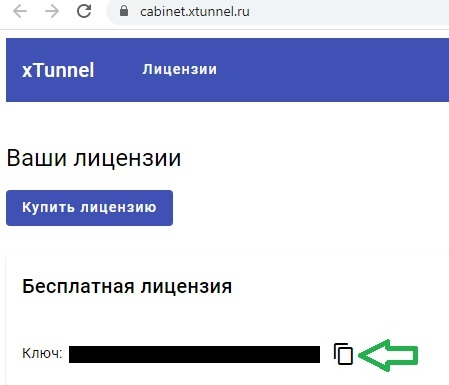

Нажмите на значок ключа (1) на левой панели меню коллаба, вставьте скопированный секретный ключ API в ячейку (4), впишите название ключа XTUNNEL_API_KEY в ячейку (3) и разрешите доступ к этому ключу (2)

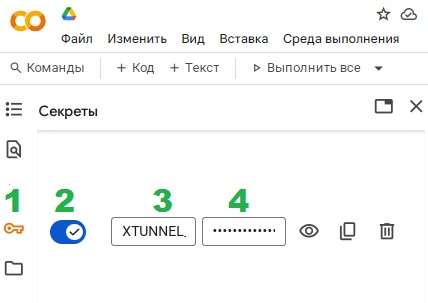

In [ ]:
import os
from google.colab import userdata
os.environ["XTUNNEL_API_KEY"]=userdata.get('XTUNNEL_API_KEY') #<- пароли в коде не храним

In [ ]:
!wget -O xt.zip https://github.com/xtunnel-dev/xtunnel-binaries/raw/refs/heads/main/1.0.20/xtunnel.linux-x64.1.0.20.zip
!unzip xt.zip
!./xtunnel -k $XTUNNEL_API_KEY

In [ ]:
!pip install fastapi uvicorn scalar_doc nest_asyncio -qqq

In [ ]:
%%writefile app.py
from fastapi import FastAPI, responses
from scalar_doc import ScalarConfiguration, ScalarDoc
import nest_asyncio
import threading
import asyncio
nest_asyncio.apply()

DESCRIPTION = """
# Автодокументация

## Раздел

### Автодокументация

Описание сервера
"""

app = FastAPI(title="Test", description=DESCRIPTION, docs_url=None, redoc_url=None)
docs = ScalarDoc.from_spec(spec=app.openapi_url, mode="url")

@app.post("/foo")
def post_foo(a: str):
    return a + " - ok"


@app.get("/docs", include_in_schema=False)
def get_docs():
    docs_html = docs.to_html()
    return responses.HTMLResponse(docs_html)


@app.get("/docs2", include_in_schema=False)
def get_docs2():
    docs = ScalarDoc.from_spec("http://localhost/openapi.json", mode="url")
    docs.set_title("Автодокументация")
    docs.set_configuration(ScalarConfiguration())
    docs_html = docs.to_html()
    return responses.HTMLResponse(docs_html)

In [ ]:
print(f"Скопируйте адрес Public address, вставьте его в адресную строку браузера, добавьте /docs, нажмите Enter")
!sleep 15 & uvicorn --host 0.0.0.0 --port 8001 app:app  & ./xtunnel http 8001 & wait

%%html
Сразу тестируйте свой код

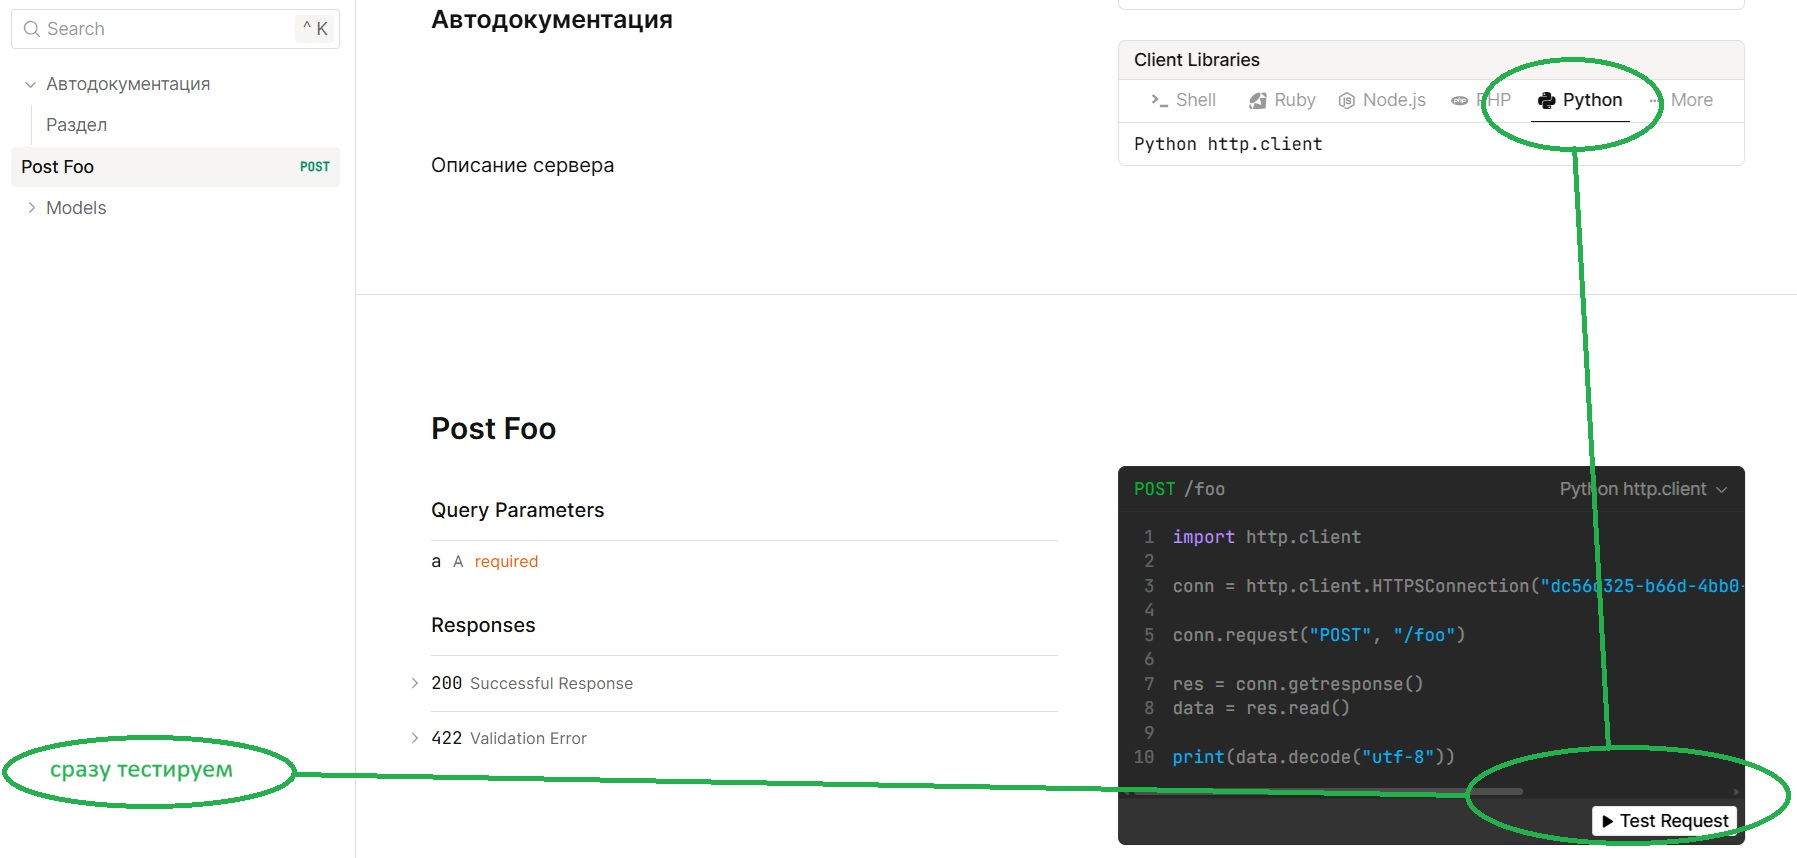

## Итоговое оформление


1. Проверьте, что ноутбук запускается.  
2. Сформулируйте ниже 5–8 выводов, когда стоит применять подход code-first и почему чаще стоит придерживаться подхода API-first.  



## Примечание

Сохраните код работоспособного сервера из [ячейки](#scrollTo=EQRTmZPa2hi1).

Этот сервис пригодится для создания контейнеризированного приложения в ДЗ 4.

In [16]:
import http.server
import socketserver
import json
import re
import threading

# --- In-memory database ---
items_db = {str(k): v for k, v in df.to_dict(orient="index").items()}
next_id = len(items_db)

def run_server():
    print(f"Serving at port {PORT} in a separate thread...")
    httpd.serve_forever()

def stop_server(timeout=0):
    print("Stopping server...")
    httpd.shutdown()
    httpd.server_close()
    time.sleep(timeout)
    print("Server stopped.")

class SimpleCRUDHandler(http.server.BaseHTTPRequestHandler):

    def _send_xml_response(self, status_code, xml_data):
        self.send_response(status_code)
        self.send_header("Content-type", "application/xml")
        self.end_headers()
        self.wfile.write(xml_data.encode("utf-8"))

    def _to_xml(self, data, root_tag="items", item_tag="item"):
        if isinstance(data, list):
            items_xml = "".join(self._item_to_xml(item, item_tag) for item in data)
            return f'<?xml version="1.0" encoding="UTF-8"?><{root_tag}>{items_xml}</{root_tag}>'
        elif isinstance(data, dict):
            return f'<?xml version="1.0" encoding="UTF-8"?>{self._item_to_xml(data, item_tag)}'

    def _item_to_xml(self, item, tag='item'):
        xml = f'<{tag}>'
        for key, value in item.items():
            xml += f'<{key}>{value}</{key}>'
        xml += f'</{tag}>'
        return xml

    def _send_json_response(self, status_code, data=None):
        self.send_response(status_code)
        self.send_header('Content-type', 'application/json')
        self.end_headers()
        if data is not None:
            self.wfile.write(json.dumps(data).encode('utf-8'))

    def _parse_json_body(self):
        content_length = int(self.headers['Content-Length'])
        body = self.rfile.read(content_length)
        try:
            return json.loads(body.decode('utf-8'))
        except json.JSONDecodeError:
            return None

    def do_GET(self):
        global items_db
        match_all = re.match(r'^/items/?$', self.path)
        match_single = re.match(r'^/items/([0-9]+)/?$', self.path)

        acceptXml = "application/xml" in self.headers.get("Accept", "")
        acceptJson = "application/json" in self.headers.get("Accept", "")

        if match_all:
            if acceptXml:
                data_list = list(items_db.values())
                xml_response = self._to_xml(data_list, root_tag='items', item_tag='item')
                self._send_xml_response(200, xml_response)
            elif acceptJson:
                self._send_json_response(200, [items_db])
            else:
                self._send_json_response(200, [items_db])

        elif match_single:
            item_id = match_single.group(1)
            if item_id in items_db:
                if acceptXml:
                    xml_response = self._to_xml(items_db[item_id], root_tag='item', item_tag='item')
                    self._send_xml_response(200, xml_response)
                elif acceptJson:
                    self._send_json_response(200, items_db[item_id])
                else:
                    self._send_json_response(200, items_db[item_id])
            else:
                self._send_json_response(404, {'detail': 'Item not found'})
        else:
            self._send_json_response(404, {'detail': 'Not Found'})

    def do_POST(self):
        global items_db, next_id
        match = re.match(r'^/items/?$', self.path)
        if match:
            data = self._parse_json_body()
            if data:
                new_id = str(next_id)
                next_id += 1
                items_db[new_id] = data
                self._send_json_response(201, {'created': data})
            else:
                self._send_json_response(400, {'detail': 'Invalid JSON'})
        else:
            self._send_json_response(404, {'detail': 'Not Found'})


PORT = 8002
httpd = socketserver.TCPServer(("localhost", PORT), SimpleCRUDHandler)

server_thread = threading.Thread(target=run_server)
server_thread.daemon = True
server_thread.start()

print(f"Server started on port {PORT}. Use server_thread.join() to wait for it or stop_server() to stop it.")

Serving at port 8002 in a separate thread...Server started on port 8002. Use server_thread.join() to wait for it or stop_server() to stop it.



In [21]:
# проверяю возвращение JSON представления
!curl -H "Accept: application/json" http://localhost:8002/items/

[{"0": {"\u041d\u0430\u0438\u043c\u0435\u043d\u043e\u0432\u0430\u043d\u0438\u0435 \u0442\u043e\u0432\u0430\u0440\u0430": "\u0410\u043d\u0442\u0438\u0444\u0440\u0438\u0437 EURO G11 (-45\u00b0\u0421) \u0437\u0435\u043b\u0435\u043d\u044b\u0439, \u0441\u0438\u043b\u0438\u043a\u0430\u0442\u043d\u044b\u0439 5\u043a\u0433", "\u0426\u0435\u043d\u0430, \u0440\u0443\u0431.": 1025, "\u0421\u043a\u0438\u0434\u043a\u0430": 11, "\u041a\u0430\u0442\u0435\u0433\u043e\u0440\u0438\u044f": "\u0430\u043d\u0442\u0438\u0444\u0440\u0438\u0437", "\u0413\u043e\u0434": 2026}, "1": {"\u041d\u0430\u0438\u043c\u0435\u043d\u043e\u0432\u0430\u043d\u0438\u0435 \u0442\u043e\u0432\u0430\u0440\u0430": "\u0410\u043d\u0442\u0438\u0444\u0440\u0438\u0437 \u0433\u043e\u0442\u043e\u0432\u044b\u0439 \u0444\u0438\u043e\u043b\u0435\u0442\u043e\u0432\u044b\u0439 \u0421\u0438\u043d\u0442\u0435\u043a MULTIFREEZE 5\u043a\u0433", "\u0426\u0435\u043d\u0430, \u0440\u0443\u0431.": 250, "\u0421\u043a\u0438\u0434\u043a\u0430": 38, "\u041a

127.0.0.1 - - [26/Mar/2026 17:30:21] "GET /items/ HTTP/1.1" 200 -


In [22]:
# проверяю возвращение XML представления
!curl -H "Accept: application/xml" http://localhost:8002/items/

<?xml version="1.0" encoding="UTF-8"?><items><item><Наименование товара>Антифриз EURO G11 (-45°С) зеленый, силикатный 5кг</Наименование товара><Цена, руб.>1025</Цена, руб.><Скидка>11</Скидка><Категория>антифриз</Категория><Год>2026</Год></item><item><Наименование товара>Антифриз готовый фиолетовый Синтек MULTIFREEZE 5кг</Наименование товара><Цена, руб.>250</Цена, руб.><Скидка>38</Скидка><Категория>антифриз</Категория><Год>2025</Год></item><item><Наименование товара>Антифриз G11 зеленый</Наименование товара><Цена, руб.>120</Цена, руб.><Скидка>61</Скидка><Категория>антифриз</Категория><Год>2025</Год></item><item><Наименование товара>Антифриз Antifreeze OEM China OAT red -40 5кг</Наименование товара><Цена, руб.>390</Цена, руб.><Скидка>65</Скидка><Категория>антифриз</Категория><Год>2025</Год></item><item><Наименование товара>Антифриз G11 зеленый</Наименование товара><Цена, руб.>135</Цена, руб.><Скидка>93</Скидка><Категория>антифриз</Категория><Год>2026</Год></item><item><Наименование товар

127.0.0.1 - - [26/Mar/2026 17:30:24] "GET /items/ HTTP/1.1" 200 -


In [ ]:
# останавливаю сервер
stop_server(httpd)